In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid")

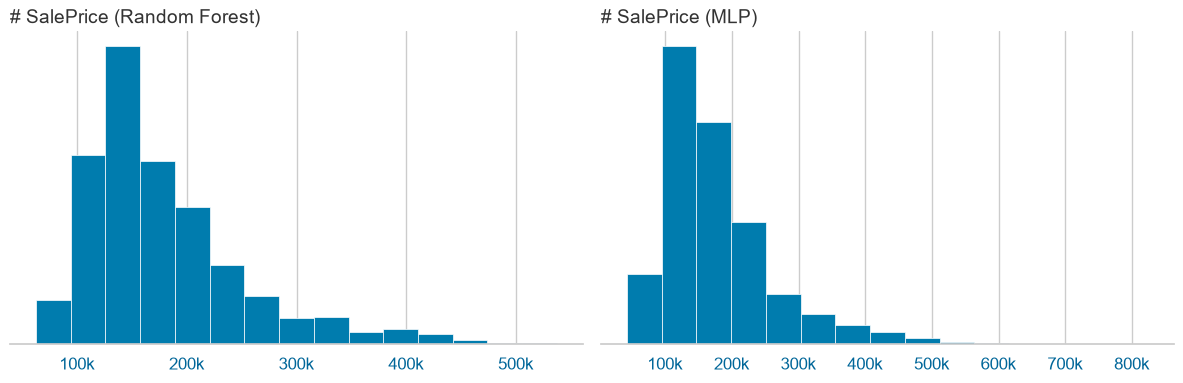

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

kaggle_blue = '#007cae'

axes[0].hist(sub_rf['SalePrice'], bins=15, color=kaggle_blue, edgecolor='white', linewidth=0.5)
axes[0].set_title('# SalePrice (Random Forest)', loc='left', fontsize=14, color='#333333')

axes[1].hist(sub_mlp['SalePrice'], bins=15, color=kaggle_blue, edgecolor='white', linewidth=0.5)
axes[1].set_title('# SalePrice (MLP)', loc='left', fontsize=14, color='#333333')

for ax in axes:
    
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))
    ax.tick_params(axis='x', colors='#006699', labelsize=12) 
    
    ax.get_yaxis().set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()
plt.show()

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
test_ids = test['Id']

cat_col_train = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageQual', 'GarageCond']
ncat_col_train = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']
for i in cat_col_train: train[i] = train[i].fillna(train[i].mode()[0])
for j in ncat_col_train: train[j] = train[j].fillna(train[j].mean())

cat_col_test = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageQual', 'GarageCond', 'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']
ncat_col_test = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']
for i in cat_col_test: test[i] = test[i].fillna(test[i].mode()[0])
for j in ncat_col_test: test[j] = test[j].fillna(test[j].mean())


to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
train.drop(columns=to_drop, inplace=True)
test.drop(columns=to_drop, inplace=True)


train['TotalHouseArea'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalHouseArea'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']


final_df = pd.concat([train, test], axis=0)
final_df = pd.get_dummies(final_df, drop_first=True).astype(float)
final_df = final_df.loc[:, ~final_df.columns.duplicated()]

df_train = final_df.iloc[:1460, :]
df_test = final_df.iloc[1460:, :].drop('SalePrice', axis=1)
X = df_train.drop('SalePrice', axis=1)
y = df_train['SalePrice']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(df_test)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Tiền xử lý hoàn tất! Kích thước tập Train:", X_train.shape)

Tiền xử lý hoàn tất! Kích thước tập Train: (1168, 236)


Đào tạo MLP hoàn tất!


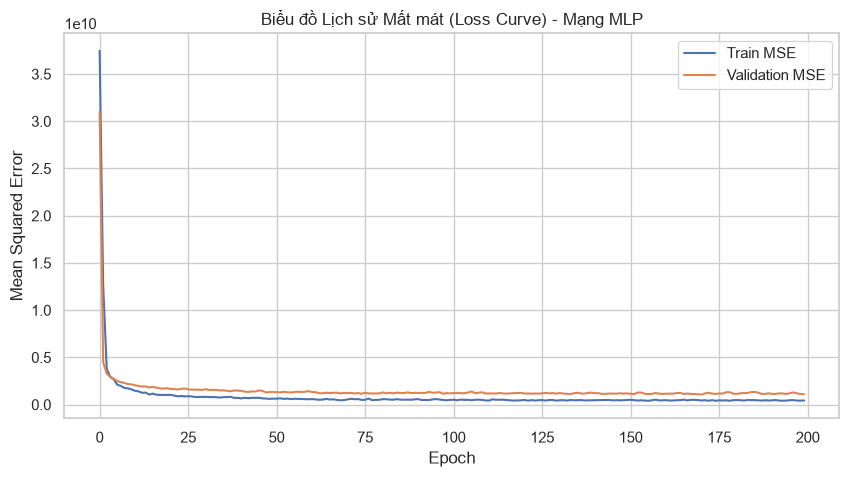

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)

class HousePriceMLP(nn.Module):
    def __init__(self, input_dim):
        super(HousePriceMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.network(x)

mlp_model = HousePriceMLP(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.01)

# Lưu trữ loss để vẽ biểu đồ
history_train_loss = []
history_val_loss = []

epochs = 200
for epoch in range(epochs):
    mlp_model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        loss = criterion(mlp_model(inputs), targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    mlp_model.eval()
    with torch.no_grad():
        val_loss = criterion(mlp_model(X_val_tensor), y_val_tensor).item()
        
    history_train_loss.append(running_loss/len(train_loader))
    history_val_loss.append(val_loss)

print("Đào tạo MLP hoàn tất!")

plt.figure(figsize=(10, 5))
plt.plot(history_train_loss, label='Train MSE')
plt.plot(history_val_loss, label='Validation MSE')
plt.title('Biểu đồ Lịch sử Mất mát (Loss Curve) - Mạng MLP')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()

In [12]:
# RF
sub_rf = pd.DataFrame({'Id': test_ids, 'SalePrice': rf_model.predict(X_test_scaled)})
sub_rf.to_csv('submission_rf.csv', index=False)

# MLP
mlp_model.eval()
with torch.no_grad():
    preds = mlp_model(torch.tensor(X_test_scaled, dtype=torch.float32)).numpy().flatten()
sub_mlp = pd.DataFrame({'Id': test_ids, 'SalePrice': preds})
sub_mlp.to_csv('submission_mlp.csv', index=False)

print("Đã tạo thành công 2 file submission!")

Đã tạo thành công 2 file submission!
